<center>

# **Министерство науки и высшего образования Российской Федерации**
# ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ
# **НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО**
# ITMO University

## ФАКУЛЬТЕТ ПРИКЛАДНОЙ ИНФОРМАТИКИ

<br>
<br>

### Отчет по лабораторной работе №1
### по дисциплине «Алгоритмы и структуры данных»
### Тема: Жадные алгоритмы. Динамическое программирование №2
### Вариант 5

<br>
<br>

</center>

<div style="text-align: right; margin-right: 50px;">

**Выполнила:**
Кулакова Е. А.

**Поток:**
АиСД K24 ЯМ 1.1

<br>

**Проверил:**
Харлунин А. А.

</div>

<br>
<br>
<br>

<center>
<br>
<br>
Санкт-Петербург
2026 г.
<br>
<br>
</center>

In [1]:
from measurments import *
from generators import *
import numpy as np

# Задачи по варианту

## 2 задача. Заправки (0.5 балла)

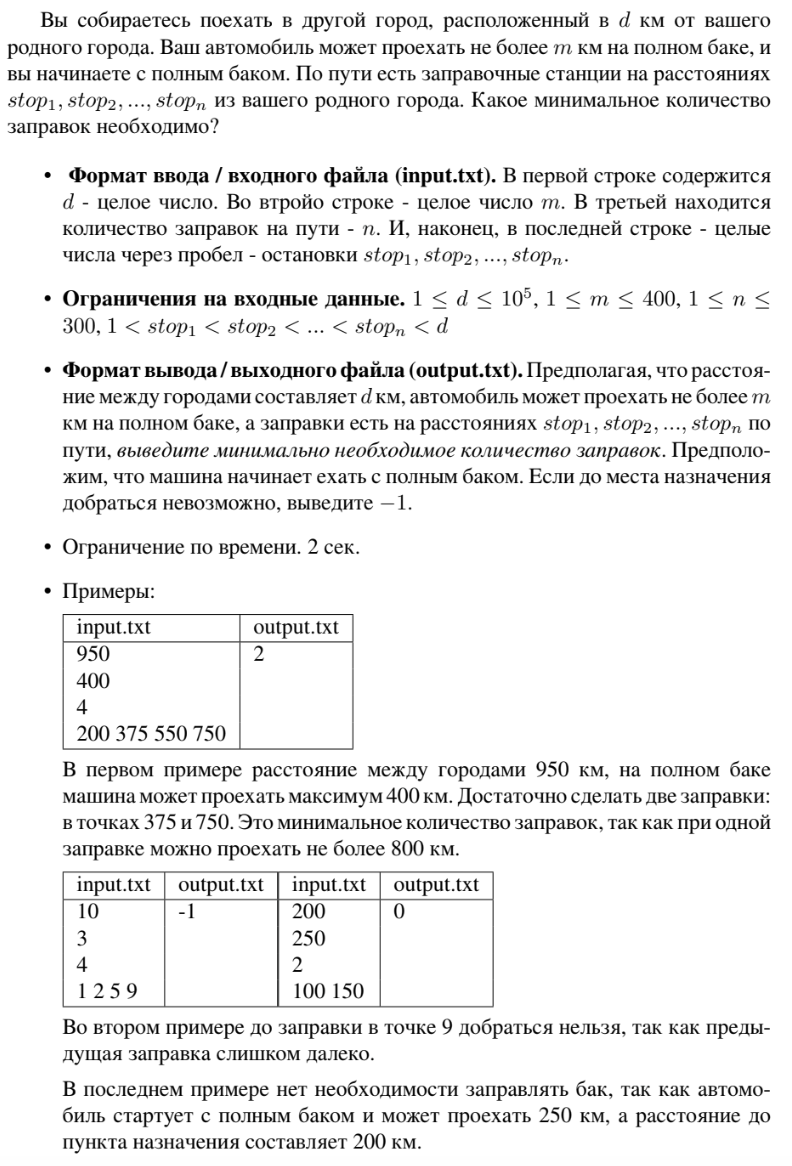

In [2]:
@measure_performance
def gas_stations(d, m, stations, n=0):
    if d <= m:
        return 0
    if d - stations[-1] > m:
        print(f'last gas station is {d - stations[-1]} away from destination, power reserve is {m}')
        return -1
    count = 0
    last_stop = 0
    for s in range(n):
        station = stations[s]
        prev_station = stations[s-1]
        if station - prev_station > m:
            print(f'distance between stations {s} and {s+1} is {station - prev_station}, power reserve is {m}')
            return -1
        if station - last_stop > m:
            count += 1
            last_stop = prev_station
    if d - last_stop > m:
        count += 1
    return count

### Результат работы кода на примерах из текста задачи:

#### ex1

In [3]:
gas_stations(950, 400, [200, 375, 550, 750], n=4)


--- Performance Report ---
Function: gas_stations(n=4)
Execution time: 0.000033 seconds
Peak memory: 0.000198 MB
------------------------------


2

#### ex2

In [4]:
gas_stations(10, 3, [1, 2, 5, 9], n=4)

distance between stations 3 and 4 is 4, power reserve is 3

--- Performance Report ---
Function: gas_stations(n=4)
Execution time: 0.000159 seconds
Peak memory: 0.002850 MB
------------------------------


-1

#### ex3

In [5]:
gas_stations(200, 250, [100, 150], n=2)


--- Performance Report ---
Function: gas_stations(n=2)
Execution time: 0.000027 seconds
Peak memory: 0.000153 MB
------------------------------


0

#### ex4 (random)

In [6]:
dist, vol, num, arr = stations_generator()
print(dist, vol, num, arr)
gas_stations(dist, vol, arr, n=num)

99082 130 224 [  209   648   910  2852  2855  3328  4982  5075  5652  6250  6549  6684
  6734  6741  7171  7802  7892  8238  8710  8919 10618 10620 10770 10981
 11279 11387 11430 12765 13017 13478 14731 15067 16266 16551 16952 17229
 17403 18481 18819 18844 19648 19656 19688 19816 20125 21166 21241 21261
 21566 21643 21946 22260 22691 22927 22974 23010 24049 24513 25405 26270
 26877 27435 27832 28712 29519 29817 30028 30424 31140 31245 31636 33309
 33347 35388 35518 35827 36126 36590 37095 37437 37473 37486 37633 37701
 37811 37925 37967 37995 38984 39010 39041 39072 39639 39953 41297 41549
 41901 41914 41976 42189 42809 43677 44404 45129 45398 46661 47743 47893
 48583 48647 48932 49487 49692 50150 50352 50856 51085 51236 51503 51949
 52581 53237 53996 54497 54768 54936 55206 55229 55572 55752 56101 56465
 56858 57516 57561 58018 58039 58056 58487 59560 59633 60118 61297 62156
 62211 62369 62375 63147 63483 64028 64463 65007 65253 65730 65907 66465
 66494 66511 66728 67281 67313 68554 

-1

### Результат работы кода на максимальных и минимальных значениях:

#### ex5 (max)

In [7]:
dist, vol, num, arr = stations_generator(10**5, 400, 300)
print(dist, vol, num, arr)
gas_stations(dist, vol, arr, n=num)

100000 400 300 [  395   693   990  1827  1895  1960  2380  2520  2562  3119  3291  3486
  4054  4177  4393  4474  5154  5437  5812  6057  6244  7408  7435  7629
  8255  8408  8932  9046 10322 10626 11351 11896 11898 13450 13503 14001
 14046 14403 15013 15387 15525 15554 16006 16483 17005 19310 19702 19974
 20723 21031 21064 21223 21527 21976 22562 22962 23516 24212 24327 24632
 24635 24713 25280 26324 26534 28088 28430 28983 28998 29118 29233 29486
 30425 30438 30797 31479 31618 31822 32165 32217 32283 32665 32801 33218
 33644 34200 34442 34511 34517 34643 34782 34823 34840 35204 35383 35579
 35733 35845 35985 37157 38079 38138 38729 38781 38869 38957 39450 40159
 40382 40692 40764 41117 41211 41436 41995 42367 42917 43619 43831 44112
 44273 44352 44639 44707 44928 45025 45217 45371 45400 45708 45788 45799
 45801 46241 47350 47718 48203 48781 48995 49475 49704 49941 50124 50161
 50306 50373 50419 50847 52299 52410 52549 52732 53236 53297 53846 53850
 54003 54039 54148 54213 54539 55189

-1

#### ex6 (min)

In [8]:
dist, vol, num, arr = stations_generator(1, 1, 1)
print(dist, vol, num, arr)
gas_stations(dist, vol, arr, n=num)

1 1 1 1

--- Performance Report ---
Function: gas_stations(n=1)
Execution time: 0.000012 seconds
Peak memory: 0.000153 MB
------------------------------


0

| | Время выполнения | Затраты памяти |
|---|------------------|----------------|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.000006 сек     | 0.00 Мб        |
| Пример из задачи |                  |                |
| Пример из задачи |                  |                |
| Верхняя граница диапазона значений входных данных из текста задачи |                  |                |

## 4 задача. Сбор подписей (0.5 балла)

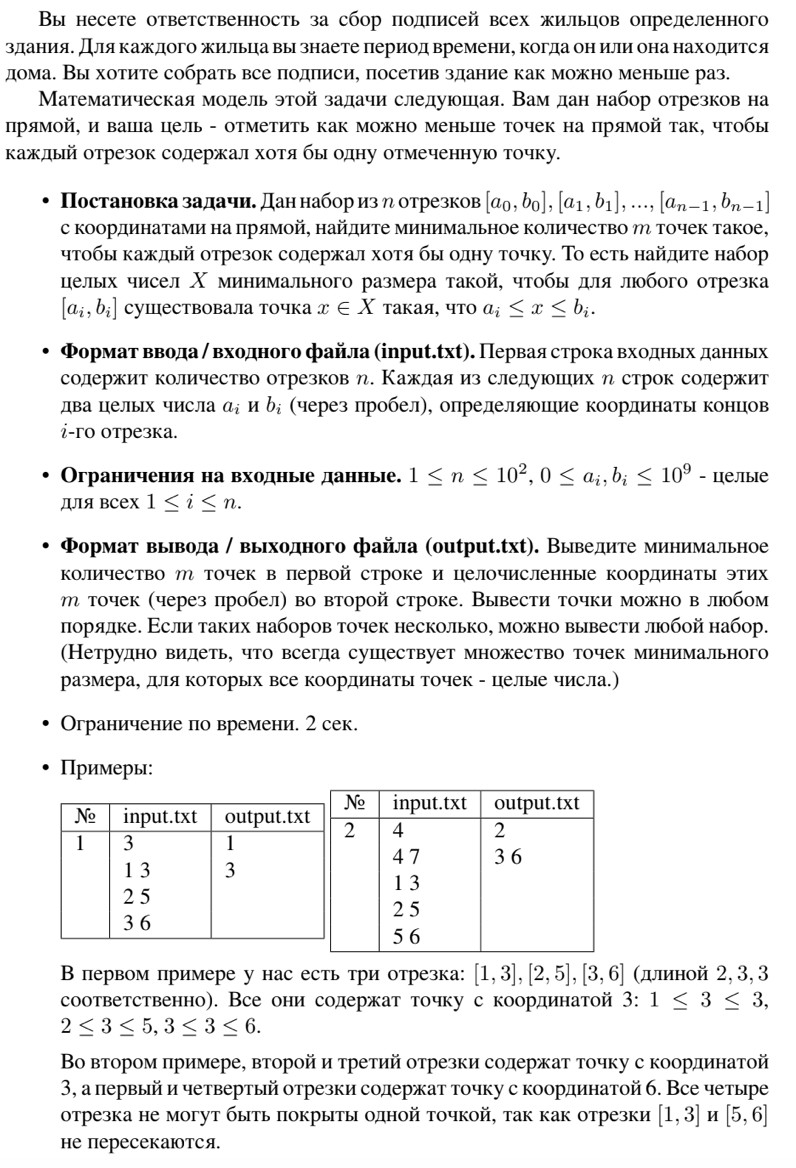

In [9]:
def partition3(A, l, r):
    x = A[l][1]
    lt = l
    gt = r
    i = l
    while i <= gt:
        if A[i][1] < x:
            A[lt], A[i] = A[i], A[lt]
            lt += 1
            i += 1
        elif A[i][1] > x:
            A[i], A[gt] = A[gt], A[i]
            gt -= 1
        else:
            i += 1
    return lt, gt

def randomized_quick_sort(A, l, r):
    if l < r:
        k = random.randint(l, r)
        A[l], A[k] = A[k], A[l]
        m1, m2 = partition3(A, l, r)
        randomized_quick_sort(A, l, m1 - 1)
        randomized_quick_sort(A, m2 + 1, r)
    return A

In [10]:
import random

@measure_performance
def segments_intersection(segments, n=0):
    if n == 1:
        return 1, random.randint(segments[0][0], segments[0][1])
    if n == 2:
        if segments[0][1] <= segments[1][0]:
            return 1, segments[0][1]
        elif segments[1][1] <= segments[0][0]:
            return 1, segments[1][1]
        else:
            return 2, segments[0][1], segments[1][0]
    else:
        sorted_segments = randomized_quick_sort(segments, 0, n-1)
        b_current = sorted_segments[0][1]
        count = 1
        dots = [b_current]
        for segm in sorted_segments[1:]:
            if b_current >= segm[0]:
                continue
            else:
                b_current = segm[1]
                dots.append(b_current)
                count += 1
        return count, dots

In [11]:
def is_valid(segments, points):
    for a, b in segments:
        # Проверяем, есть ли хотя бы одна точка из points в отрезке [a, b]
        if not any(a <= p <= b for p in points):
            return False, (a, b) # Вернет отрезок, который не покрыт
    return True, None

In [12]:
segments_intersection([(1, 3), (2, 5), (3, 6)], n=3)


--- Performance Report ---
Function: segments_intersection(n=3)
Execution time: 0.000050 seconds
Peak memory: 0.000183 MB
------------------------------


(1, [3])

In [13]:
segments_intersection([(4, 7), (1, 3), (2, 5), (5, 6)], n=4)


--- Performance Report ---
Function: segments_intersection(n=4)
Execution time: 0.000090 seconds
Peak memory: 0.000244 MB
------------------------------


(2, [3, 6])

In [14]:
num, arr = segments_generator(100)
print(num, arr)
min_num, min_arr = segments_intersection(arr, n=num)
valid, failed_segment = is_valid(arr, min_arr)
if valid:
    print("Алгоритм отработал верно: все отрезки покрыты!")
else:
    print(f"Ошибка! Отрезок {failed_segment} не покрыт.")
print(min_num, min_arr)

100 [(539309060, 920393037), (105229729, 961922367), (919012971, 981994224), (981083227, 983703161), (861144858, 908306821), (167018918, 377998292), (908062140, 939372867), (788157915, 910518713), (500797959, 571289245), (716867828, 960022153), (374688881, 843053643), (774191115, 916576971), (271649297, 836755133), (391461760, 515937052), (793493954, 837739679), (407934569, 487078009), (530552785, 584073046), (587983249, 684090763), (534291934, 946520088), (220261205, 804441946), (103013610, 978960928), (231757513, 446662806), (75139537, 855081782), (181939364, 898178867), (276900223, 896689573), (937851304, 955867071), (658834711, 793816870), (709609670, 983588492), (563404596, 950185707), (149308459, 654559070), (427757180, 913440559), (251419769, 765856912), (63716194, 118355990), (797279907, 817038648), (457834788, 646273187), (96156660, 731726371), (268705220, 277851012), (857300943, 883344845), (261836083, 337733501), (580888541, 958838899), (380295987, 866627200), (281078134, 28

## 12 задача. Последовательность (1 балл)

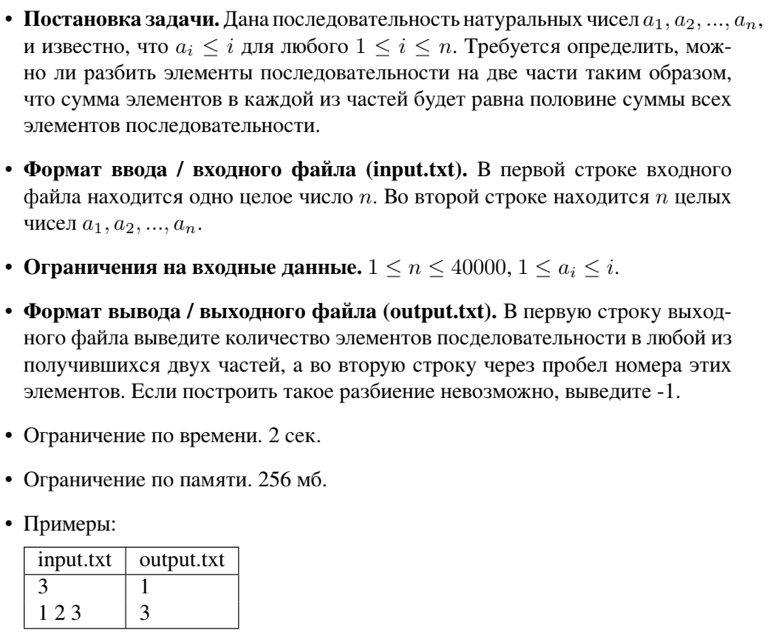

In [15]:
def partition3_inv(A, l, r):
    x = A[l][0]
    lt = l
    gt = r
    i = l
    while i <= gt:
        if A[i][0] < x:
            A[gt], A[i] = A[i], A[gt]
            lt += 1
            i += 1
        elif A[i][0] > x:
            A[i], A[lt] = A[lt], A[i]
            gt -= 1
        else:
            i += 1
    return lt, gt

def randomized_quick_sort_inv(A, l, r):
    if l < r:
        k = random.randint(l, r)
        A[l], A[k] = A[k], A[l]
        m1, m2 = partition3_inv(A, l, r)
        randomized_quick_sort_inv(A, l, m1 - 1)
        randomized_quick_sort_inv(A, m2 + 1, r)
    return A

In [16]:
def partition3_norm(A, l, r):
    x = A[l]
    lt = l
    gt = r
    i = l
    while i <= gt:
        if A[i] < x:
            A[lt], A[i] = A[i], A[lt]
            lt += 1
            i += 1
        elif A[i] > x:
            A[i], A[gt] = A[gt], A[i]
            gt -= 1
        else:
            i += 1
    return lt, gt

def randomized_quick_sort_norm(A, l, r):
    if l < r:
        k = random.randint(l, r)
        A[l], A[k] = A[k], A[l]
        m1, m2 = partition3_norm(A, l, r)
        randomized_quick_sort_norm(A, l, m1 - 1)
        randomized_quick_sort_norm(A, m2 + 1, r)
    return A

In [17]:
@measure_base_performance
def subsequence1(sequence, n=0):
    if n == 1:
        return -1

    elif n == 2:
        if sequence[0] != sequence[1]:
            return -1
        else:
            return 1, 1

    else:
        if sum(sequence) % 2 != 0:
            print('sum is not even')
            return -1
        else:

            target = sum(sequence) // 2
            current_mask = 1
            masks = [0] * n

            for i in range(n):
                masks[i] = current_mask
                current_mask |= (current_mask << sequence[i])

            if not (current_mask >> target) & 1:
                print('sum is unreachable')
                return -1

            inds_subseq = []
            curr_target = target

            for i in range(n - 1, -1, -1):

                if sequence[i] == curr_target:
                    inds_subseq.append(i + 1)
                    curr_target -= sequence[i]
                    return len(inds_subseq), randomized_quick_sort_norm(inds_subseq, 0, len(inds_subseq)-1)

                if not (masks[i] >> curr_target) & 1:
                    inds_subseq.append(i + 1)
                    curr_target -= sequence[i]

                if curr_target == 0: return len(inds_subseq), randomized_quick_sort_norm(inds_subseq, 0, len(inds_subseq)-1)

            return -1

In [18]:
@measure_base_performance
def subsequence(sequence, n=0):
    if n < 2: return -1

    total_sum = sum(sequence)
    if total_sum % 2 != 0:
        print('sum is not even')
        return -1

    target = total_sum // 2
    K = 100

    checkpoints = {}
    current_mask = 1

    for i in range(n):
        if i % K == 0:
            checkpoints[i] = current_mask
        current_mask |= (current_mask << sequence[i])

    # Проверка достижимости
    if not (current_mask >> target) & 1:
        print('sum is unreachable')
        return -1

    inds_subseq = []
    curr_target = target

    i = n - 1
    while i >= 0:
        cp_idx = (i // K) * K
        temp_mask = checkpoints[cp_idx]
        local_masks = []

        for j in range(cp_idx, i + 1):
            local_masks.append(temp_mask)
            temp_mask |= (temp_mask << sequence[j])

        for j in range(i, cp_idx - 1, -1):
            val = sequence[j]
            mask_before_val = local_masks[j - cp_idx]

            if val == curr_target:
                inds_subseq.append(j + 1)
                curr_target = 0
                break

            if curr_target >= val and not (mask_before_val >> curr_target) & 1:
                inds_subseq.append(j + 1)
                curr_target -= val

            if curr_target == 0: break

        if curr_target == 0: break
        i = cp_idx - 1

    if curr_target == 0:
        return len(inds_subseq), randomized_quick_sort_norm(inds_subseq, 0, len(inds_subseq)-1)
    return -1

In [19]:
subsequence([1, 2, 3], n=3)


--- Performance Report ---
Function: subsequence(n=3)
Execution time: 0.011919 seconds
Peak memory: 54.62 MB (55936.00 KB)
------------------------------


(1, [3])

In [20]:
num, arr = sequences_generator(4000)
print(num, arr)
subsequence(arr, n=num)

4000 [1, 1, 1, 4, 1, 1, 5, 4, 2, 2, 5, 12, 13, 5, 8, 12, 1, 16, 3, 10, 9, 6, 20, 13, 4, 26, 21, 18, 1, 6, 1, 31, 24, 19, 1, 29, 4, 28, 35, 40, 9, 38, 31, 37, 1, 10, 14, 35, 4, 38, 19, 7, 35, 20, 11, 21, 29, 22, 16, 16, 36, 12, 63, 45, 47, 21, 9, 42, 34, 63, 56, 42, 71, 50, 38, 56, 69, 9, 11, 19, 75, 81, 57, 40, 25, 77, 6, 9, 51, 62, 18, 82, 17, 40, 53, 86, 53, 95, 52, 77, 41, 8, 20, 15, 11, 38, 20, 49, 2, 99, 89, 48, 50, 13, 102, 100, 40, 78, 57, 24, 35, 41, 114, 19, 117, 111, 92, 16, 62, 36, 61, 58, 124, 66, 91, 117, 105, 20, 53, 112, 115, 21, 53, 83, 50, 100, 134, 147, 95, 132, 51, 36, 125, 149, 17, 94, 4, 4, 141, 93, 132, 14, 119, 73, 6, 10, 137, 141, 58, 77, 138, 45, 32, 15, 68, 122, 45, 156, 2, 87, 145, 86, 87, 24, 79, 21, 96, 61, 140, 112, 147, 162, 110, 85, 193, 160, 120, 195, 29, 63, 48, 185, 49, 41, 21, 7, 2, 23, 36, 159, 151, 120, 211, 144, 103, 11, 132, 137, 195, 83, 147, 72, 192, 107, 99, 200, 212, 30, 134, 83, 96, 94, 195, 124, 202, 198, 214, 156, 221, 54, 23, 96, 63, 51, 

-1

## 14 задача. Максимальное значение арифметического выражения (2 балла)

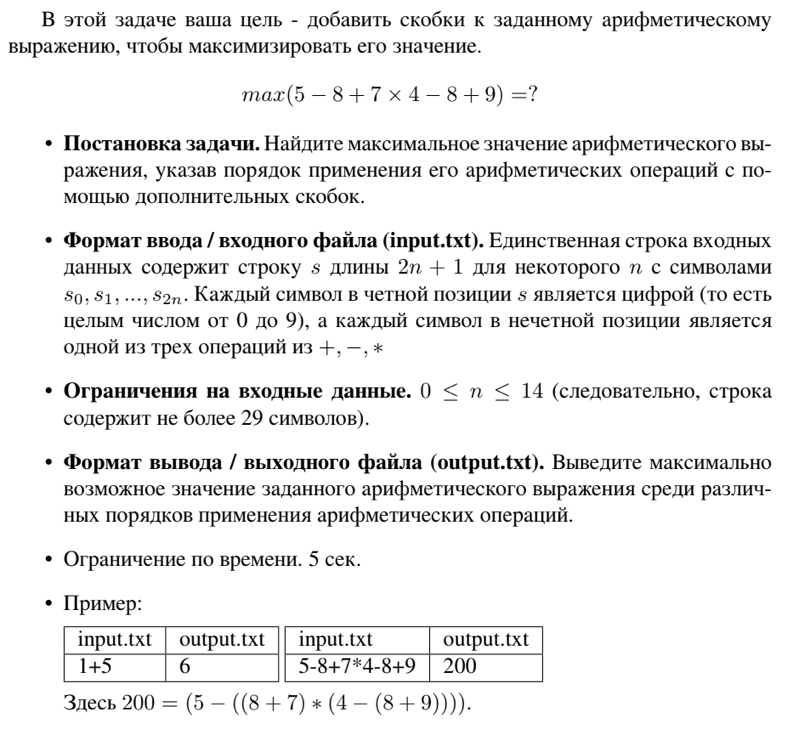

In [21]:
def arithmetics(d1, d2, op):
    if op == '+':
        return d1 + d2
    elif op == '-':
        return d1 - d2
    elif op == '*':
        return d1 * d2

def listed_seq(stroka):
    lstr = list(stroka)
    digits = [int(lstr[k]) for k in range(len(lstr)) if k % 2 == 0]
    operations = [lstr[k] for k in range(len(lstr)) if k % 2 == 1]
    return digits, operations

@measure_performance
def brackets_seq(stroka, n=None):
    digits, ops = listed_seq(stroka)
    if len(digits) == 2:
        return arithmetics(digits[0], digits[1], ops[0])
    elif len(digits) == 1:
        return digits[0]
    else:
        mins = [[0] * len(digits) for _ in range(len(digits))]
        maxs = [[0] * len(digits) for _ in range(len(digits))]
        for i in range(len(digits)):
            mins[i][i], maxs[i][i] = digits[i], digits[i]

        for l in range(2, len(digits) + 1):
            for i in range(len(digits) - l + 1):
                results = []
                j = i + l - 1
                for k in range(i, j):
                    results.append(arithmetics(maxs[i][k], maxs[k+1][j], ops[k]))
                    results.append(arithmetics(maxs[i][k], mins[k+1][j], ops[k]))
                    results.append(arithmetics(mins[i][k], maxs[k+1][j], ops[k]))
                    results.append(arithmetics(mins[i][k], mins[k+1][j], ops[k]))
                mins[i][j], maxs[i][j] = min(results), max(results)
        return maxs[0][-1]

In [22]:
ex1 = '1+5'
brackets_seq(ex1, n=len(ex1))


--- Performance Report ---
Function: brackets_seq(n=3)
Execution time: 0.000027 seconds
Peak memory: 0.000313 MB
------------------------------


6

In [23]:
ex2 = '5-8+7*4-8+9'
brackets_seq(ex2, n=len(ex2))


--- Performance Report ---
Function: brackets_seq(n=11)
Execution time: 0.000352 seconds
Peak memory: 0.001816 MB
------------------------------


200

In [24]:
expr, lngth = expression_generator(14)
print(f'original expression: {expr}')

brackets_seq(expr, n=lngth)

original expression: 5+4-1+4-2-8-1-2*5-6*5-0+2+5

--- Performance Report ---
Function: brackets_seq(n=29)
Execution time: 0.002113 seconds
Peak memory: 0.008041 MB
------------------------------


1188

In [25]:
expr, lngth = expression_generator(13)
print(f'original expression: {expr}')

brackets_seq(expr, n=lngth)

original expression: 7*6+6*5+4*9*3-0+2*5+8+1+4

--- Performance Report ---
Function: brackets_seq(n=27)
Execution time: 0.001819 seconds
Peak memory: 0.007050 MB
------------------------------


612360

## 21 задача. Игра в дурака (3 балла)

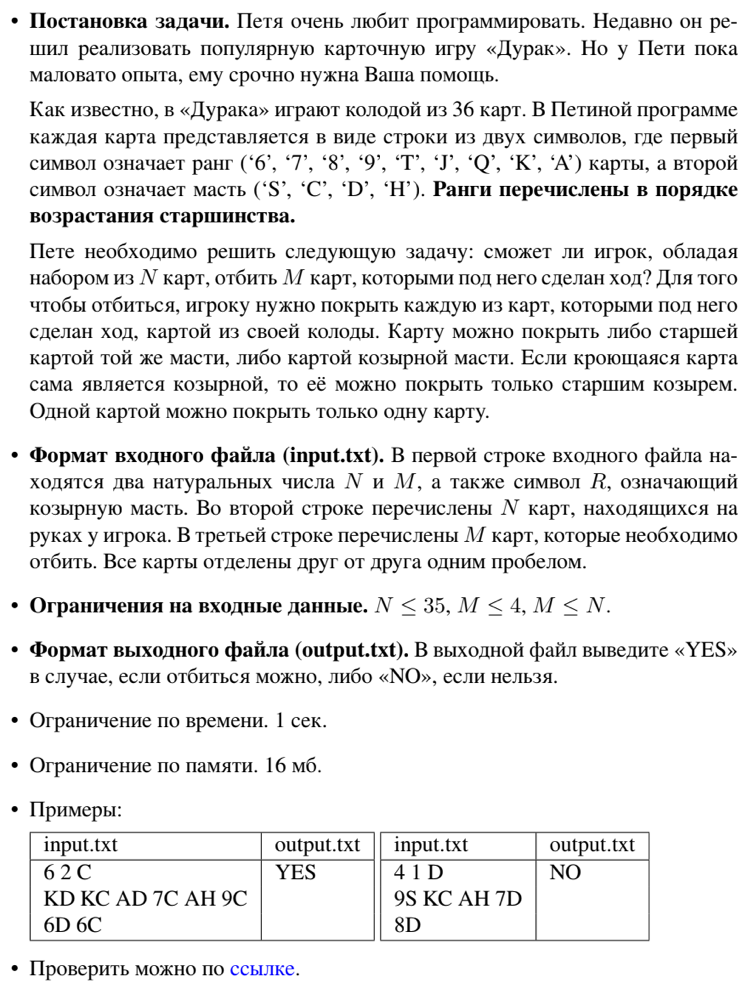

In [26]:
def cards_unpacking(cards_stroka):
    return [(card[0], card[1]) for card in cards_stroka.split()]

def can_beat(attacker, defender, trump, order):
    if attacker[1] == trump:
        if defender[1] != trump:
            return True
        else:
            return order[attacker[0]] > order[defender[0]]
    else:
        if defender[1] == trump:
            return False
        else:
            return (attacker[1] == defender[1] and
                   order[attacker[0]] > order[defender[0]])

def can_cover(i, m, n, rival_cards, player_cards, used, trump):
    order = {rang: i for i, rang in enumerate(['6','7','8','9','T','J','Q','K','A'])}
    if i == m:
        return True
    else:
        for j in range(n):
            if j not in used and can_beat(player_cards[j], rival_cards[i], trump, order):
                used.append(j)
                if can_cover(i + 1, m, n, rival_cards, player_cards, used, trump):
                    return True
                used.pop()
        return False


@measure_plural_performance
def durak(trump, player_cards, rival_cards, n=None, m=None):
    player_cards = cards_unpacking(player_cards)
    rival_cards = cards_unpacking(rival_cards)
    if m == 1 and rival_cards[0][0] == 'A' and rival_cards[0][1] == trump:
        return 'NO'
    else:
        used = []
        return 'YES' if can_cover(0, m, n, rival_cards, player_cards, used, trump) else 'NO'

In [27]:
durak('C', 'KD KC AD 7C AH 9C', '6D 6C', n=6, m=2)


--- Performance Report ---
Function: durak(n=6, m=2)
Execution time: 0.000051 seconds
Peak memory: 0.00 MB
------------------------------


'YES'

In [28]:
durak('D', '9S KC AH 7D', '8D', n=4, m=1)


--- Performance Report ---
Function: durak(n=4, m=1)
Execution time: 0.000029 seconds
Peak memory: 0.00 MB
------------------------------


'NO'

In [29]:
pl_n, pl, tbl_m, tbl, trmp = cards_generator()

print(f'player cards: {pl_n}, {pl}, table cads: {tbl_m}, {tbl}')

durak(trmp, pl, tbl, n=pl_n, m=tbl_m)

player cards: 30, AC AS 8C TH JH 6D TS 9H KH 9D 7S 6H QH KC TD AH 7D 7H QS 6S TC 8H 9S 8D JS 8S AD JC JD QC, table cads: 1, 6C

--- Performance Report ---
Function: durak(n=30, m=1)
Execution time: 0.000059 seconds
Peak memory: 0.00 MB
------------------------------


'YES'

### Проверка на сайте

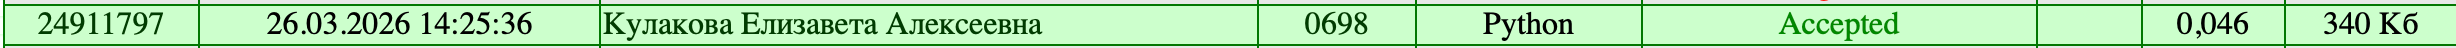

# Дополнительные задачи

## 16 задача. Продавец (2 балла)

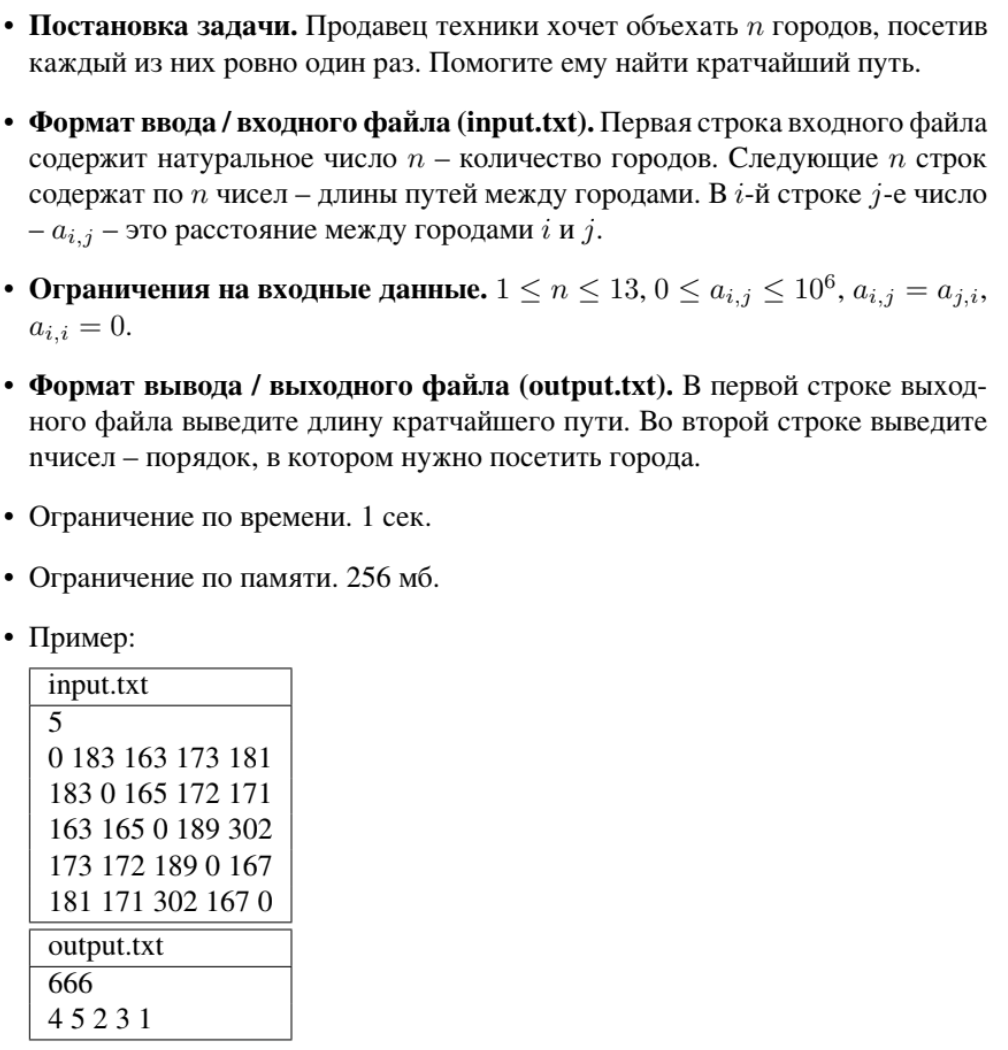

In [41]:
def routes(data):
    routes_table = []
    for row in data:
        routes_table.append([int(a) for a in row.split()])
    return routes_table

@measure_base_performance
def shortest_way(routes_table, n):
    inf = 10**9
    num_masks = 1 << n
    dp = [[inf] * n for _ in range(num_masks)]

    for i in range(n):
        dp[1 << i][i] = 0

    for mask in range(1, num_masks):
        visited = [i for i in range(n) if (mask & (1 << i))]
        not_visited = [i for i in range(n) if not (mask & (1 << i))]

        dp_mask = dp[mask]
        for u in visited:
            d_u = dp_mask[u]
            if d_u >= inf: continue

            dist_u = routes_table[u]
            for v in not_visited:
                new_mask = mask | (1 << v)
                new_dist = d_u + dist_u[v]
                if new_dist < dp[new_mask][v]:
                    dp[new_mask][v] = new_dist

    min_cost, curr_city = min(((dp[2**n - 1][i], i) for i in range(n)), key=lambda x: x[0])

    path = []
    curr_mask = num_masks - 1
    while curr_mask > 0:
        path.append(curr_city + 1)
        prev_mask = curr_mask ^ (1 << curr_city)
        if prev_mask == 0: break

        target = dp[curr_mask][curr_city]
        cur_route = dp[prev_mask]
        dist_curr = routes_table[curr_city]
        for prev_city in range(n):
            if (prev_mask & (1 << prev_city)) and \
               cur_route[prev_city] + dist_curr[prev_city] == target:
                curr_city = prev_city
                curr_mask = prev_mask
                break

    return min_cost, path[::-1]

In [43]:
shortest_way([[0, 183, 163, 173, 181], [183, 0, 165, 172, 171], [163, 165, 0, 189, 302], [173, 172, 189, 0, 167], [181, 171, 302, 167, 0]], n=5)


--- Performance Report ---
Function: shortest_way(n=5)
Execution time: 0.012551 seconds
Peak memory: 42.72 MB (43744.00 KB)
------------------------------


(666, [4, 5, 2, 3, 1])

In [46]:
num, rt = routes_generator(13)
print(rt)
shortest_way(rt, n=num)

[[0, 131356, 776008, 475504, 622520, 386441, 228581, 855611, 882235, 218015, 906338, 946379, 791940], [131356, 0, 950404, 887801, 79537, 335612, 360903, 148140, 813261, 953027, 35472, 562502, 491845], [776008, 950404, 0, 564749, 962128, 797884, 58229, 145697, 363979, 934841, 827122, 921050, 567050], [475504, 887801, 564749, 0, 901372, 146198, 852204, 289194, 77631, 227356, 311169, 101953, 359270], [622520, 79537, 962128, 901372, 0, 977747, 844931, 148086, 682602, 726346, 894788, 106586, 466977], [386441, 335612, 797884, 146198, 977747, 0, 651317, 896392, 548170, 420484, 426321, 717967, 708977], [228581, 360903, 58229, 852204, 844931, 651317, 0, 221281, 172747, 458535, 586484, 993695, 269100], [855611, 148140, 145697, 289194, 148086, 896392, 221281, 0, 990363, 830444, 938373, 848540, 303288], [882235, 813261, 363979, 77631, 682602, 548170, 172747, 990363, 0, 139864, 406600, 942600, 565313], [218015, 953027, 934841, 227356, 726346, 420484, 458535, 830444, 139864, 0, 13086, 757070, 733537

(1248029, [13, 12, 5, 8, 3, 7, 1, 2, 11, 10, 9, 4, 6])

## 22 задача. Симпатичные узоры (4 балла)

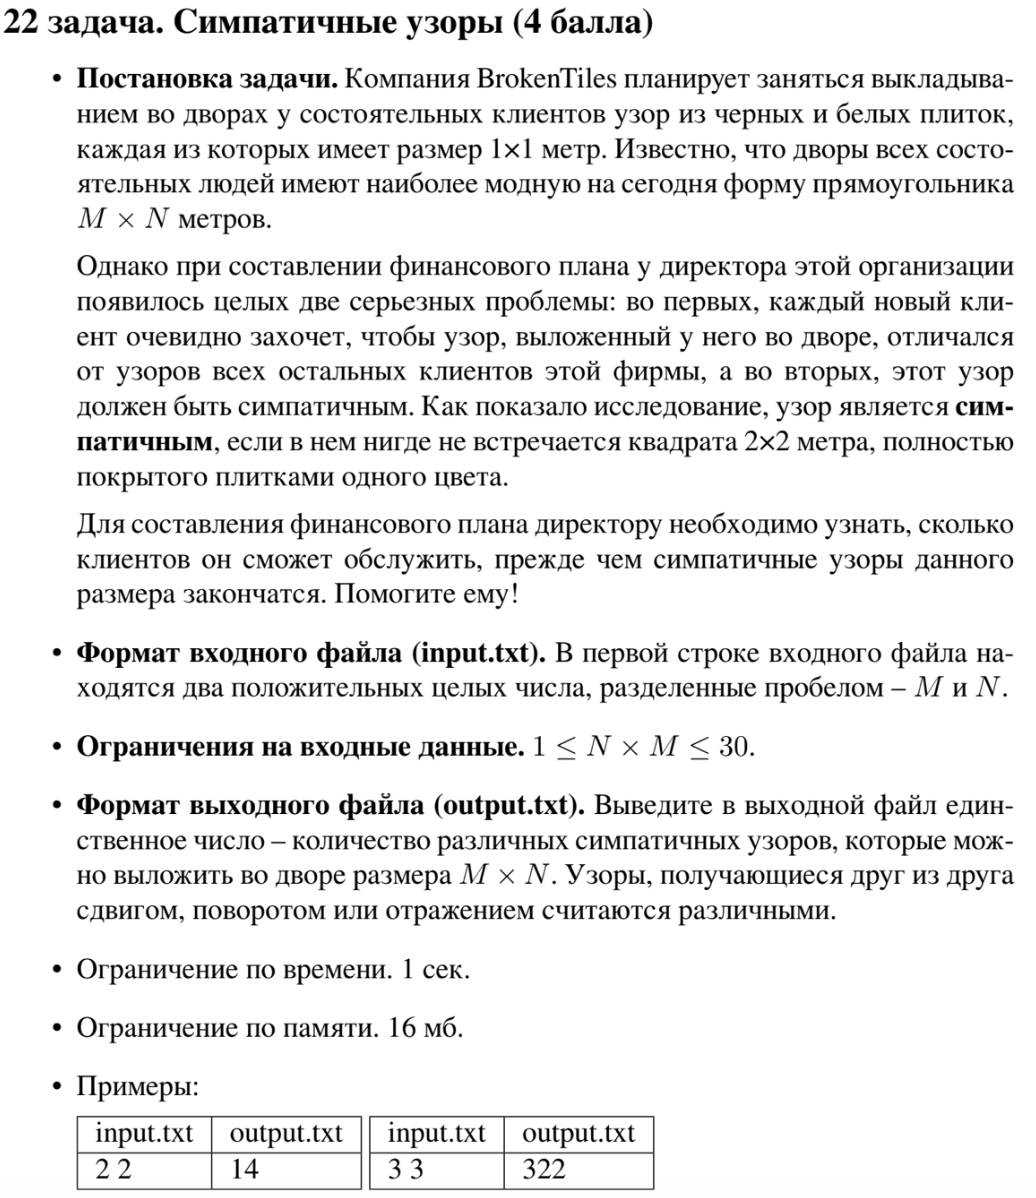

In [33]:
def is_nice(curr_mask, prev_mask, m):
    for i in range(m-1):
        p1 = (prev_mask >> i) & 1
        p2 = (prev_mask >> (i + 1)) & 1
        c1 = (curr_mask >> i) & 1
        c2 = (curr_mask >> (i + 1)) & 1

        if p1 == p2 == c1 == c2:
            return False
    return True

@measure_plural_performance
def patterns(n, m):
    if m > n: #  why does it help???? less iterations but arrays are a bit longer??
        n, m = m, n

    dp_prev = [1] * (1<<m) # начинаем с ситуации покраски одного предыдущего столбца в каком-то паттерне

    for j in range(1, n):
        dp_curr = [0] * (1<<m)
        for prev_mask in range(1<<m):
            if dp_prev[prev_mask]:
                for curr_mask in range(1<<m):
                    if is_nice(curr_mask, prev_mask, m):
                        dp_curr[curr_mask] += dp_prev[prev_mask]
        dp_prev = dp_curr[:]
    return sum(dp_prev)

In [34]:
patterns(2, 2)


--- Performance Report ---
Function: patterns(n=2, m=2)
Execution time: 0.000079 seconds
Peak memory: 0.00 MB
------------------------------


14

In [35]:
patterns(3, 3)


--- Performance Report ---
Function: patterns(n=3, m=3)
Execution time: 0.000401 seconds
Peak memory: 0.00 MB
------------------------------


322

In [36]:
N, M = square_generator()
print(N, M)
patterns(N, M)

5 6

--- Performance Report ---
Function: patterns(n=5, m=6)
Execution time: 0.025307 seconds
Peak memory: 0.00 MB
------------------------------


119310334

In [37]:
patterns(10, 3)


--- Performance Report ---
Function: patterns(n=10, m=3)
Execution time: 0.002484 seconds
Peak memory: 0.00 MB
------------------------------


144506294

In [38]:
patterns(3, 10)


--- Performance Report ---
Function: patterns(n=3, m=10)
Execution time: 0.003301 seconds
Peak memory: 0.00 MB
------------------------------


144506294

In [39]:
patterns(5, 6)


--- Performance Report ---
Function: patterns(n=5, m=6)
Execution time: 0.028497 seconds
Peak memory: 0.00 MB
------------------------------


119310334

In [40]:
patterns(2, 15)


--- Performance Report ---
Function: patterns(n=2, m=15)
Execution time: 0.001039 seconds
Peak memory: 0.00 MB
------------------------------


208199210

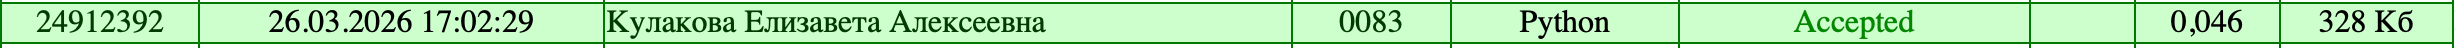